In [206]:
import pandas as pd
df = pd.read_csv("../data/raw/Energy_consumption.csv")
df.head()

,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption
0,2022-01-01 00:00:00,25.139433,43.431581,1565.693999,5,On,Off,2.774699,Monday,No,75.364373
1,2022-01-01 01:00:00,27.731651,54.225919,1411.064918,1,On,On,21.831384,Saturday,No,83.401855
2,2022-01-01 02:00:00,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,Sunday,No,78.270888
3,2022-01-01 03:00:00,20.080469,50.371637,1452.316318,1,Off,On,8.623447,Wednesday,No,56.519850
4,2022-01-01 04:00:00,23.097359,51.401421,1094.130359,9,On,Off,3.071969,Friday,No,70.811732


In [207]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Timestamp          1000 non-null   str    
 1   Temperature        1000 non-null   float64
 2   Humidity           1000 non-null   float64
 3   SquareFootage      1000 non-null   float64
 4   Occupancy          1000 non-null   int64  
 5   HVACUsage          1000 non-null   str    
 6   LightingUsage      1000 non-null   str    
 7   RenewableEnergy    1000 non-null   float64
 8   DayOfWeek          1000 non-null   str    
 9   Holiday            1000 non-null   str    
 10  EnergyConsumption  1000 non-null   float64
dtypes: float64(5), int64(1), str(5)
memory usage: 86.1 KB


,Temperature,Humidity,SquareFootage,Occupancy,RenewableEnergy,EnergyConsumption
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,24.982026,45.395412,1500.052488,4.581000,15.132813,77.055873
std,2.836850,8.518905,288.418873,2.865598,8.745917,8.144112
min,20.007565,30.015975,1000.512661,0.000000,0.006642,53.263278
25%,22.645070,38.297722,1247.108548,2.000000,7.628385,71.544690
50%,24.751637,45.972116,1507.967426,5.000000,15.072296,76.943696
75%,27.418174,52.420066,1740.340165,7.000000,22.884064,82.921742
max,29.998671,59.969085,1999.982252,9.000000,29.965327,99.201120


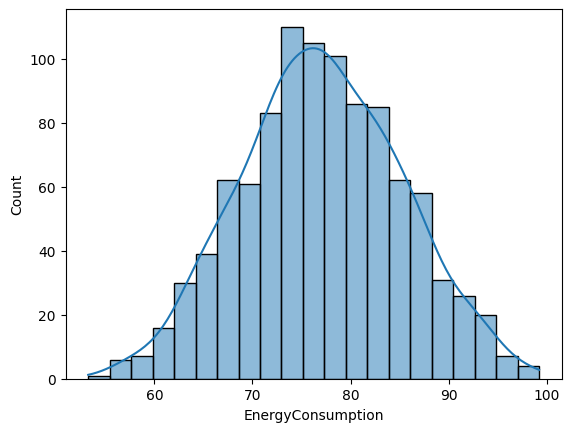

In [208]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df["EnergyConsumption"], kde=True)
plt.show()

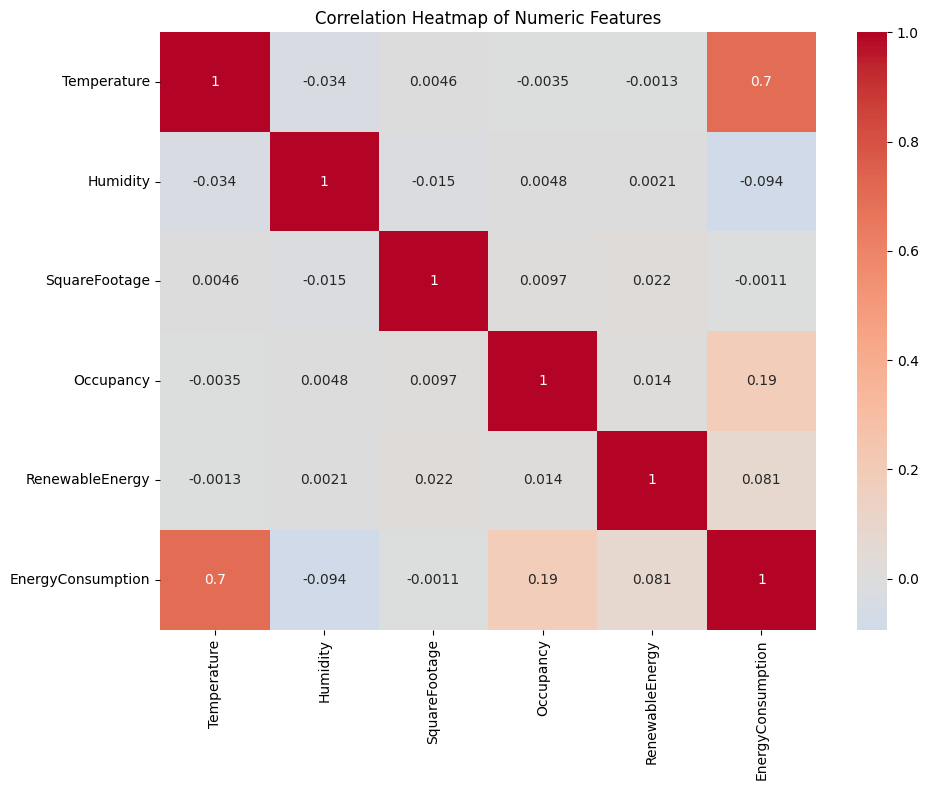

In [209]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

In [210]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df["hour"] = df["Timestamp"].dt.hour
df["day"] = df["Timestamp"].dt.day
df["month"] = df["Timestamp"].dt.month
df["year"] = df["Timestamp"].dt.year
df = df.drop("Timestamp", axis=1)
# df = pd.get_dummies(df, drop_first=True) 
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Temperature        1000 non-null   float64
 1   Humidity           1000 non-null   float64
 2   SquareFootage      1000 non-null   float64
 3   Occupancy          1000 non-null   int64  
 4   HVACUsage          1000 non-null   str    
 5   LightingUsage      1000 non-null   str    
 6   RenewableEnergy    1000 non-null   float64
 7   DayOfWeek          1000 non-null   str    
 8   Holiday            1000 non-null   str    
 9   EnergyConsumption  1000 non-null   float64
 10  hour               1000 non-null   int32  
 11  day                1000 non-null   int32  
 12  month              1000 non-null   int32  
 13  year               1000 non-null   int32  
dtypes: float64(5), int32(4), int64(1), str(4)
memory usage: 93.9 KB


,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption,hour,day,month,year
0,25.139433,43.431581,1565.693999,5,On,Off,2.774699,Monday,No,75.364373,0,1,1,2022
1,27.731651,54.225919,1411.064918,1,On,On,21.831384,Saturday,No,83.401855,1,1,1,2022
2,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,Sunday,No,78.270888,2,1,1,2022
3,20.080469,50.371637,1452.316318,1,Off,On,8.623447,Wednesday,No,56.519850,3,1,1,2022
4,23.097359,51.401421,1094.130359,9,On,Off,3.071969,Friday,No,70.811732,4,1,1,2022


Identify feature | and cleaning data to scale them and encode them
<!--
  0   Timestamp          1000 non-null   str    
  
  5   HVACUsage          1000 non-null   str    
  6   LightingUsage      1000 non-null   str    
  8   DayOfWeek          1000 non-null   str    
  9   Holiday            1000 non-null   str    
 
  1   Temperature        1000 non-null   float64
  2   Humidity           1000 non-null   float64
  3   SquareFootage      1000 non-null   float64
  4   Occupancy          1000 non-null   int64  
  7   RenewableEnergy    1000 non-null   float64

  10  EnergyConsumption  1000 non-null   float64 
  -->

In [211]:
categorical_features = ["HVACUsage", "LightingUsage", "DayOfWeek", "Holiday"]
numeric_features = ["Temperature", "Humidity", "SquareFootage", "Occupancy", "RenewableEnergy"]

target = "EnergyConsumption"

Fill missing values (if any)

In [212]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# df[numeric_features] = df[numeric_features].fillna(df[numeric_features].median())
# df[categorical_features] = df[categorical_features].fillna("Unknown")

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

df["HeatIndex"] = df["Temperature"] + 0.5 * df["Humidity"]
numeric_features.append("HeatIndex")

Split Data

In [213]:
from sklearn.model_selection import train_test_split


# X = df.drop("EnergyConsumption", axis=1) # take all columns except the target
X = df[numeric_features + categorical_features]
y = df[target] # EnergyConsumption

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# # Full pipeline with model
# model_pipeline = Pipeline([
#     ("preprocessor", preprocessor),
#     ("regressor", LinearRegression())
# ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Train Model

In [214]:
from sklearn.linear_model import LinearRegression


from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import numpy as np

def evaluate_model(X_train, X_test, y_train, y_test, model, model_name="Model") -> None:
    """
    Train a model with preprocessing and evaluate performance on the test set.

    Parameters:
    - X_train, X_test, y_train, y_test: your train/test split data
    - model: any sklearn regressor object
    - model_name: string for printing
    """
    # Create pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),  # your ColumnTransformer
        ("regressor", model)
    ])
    
    # Train
    model_pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    print(f"--- {model_name} ---")
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R²:", r2_score(y_test, y_pred))
    print("\n")  # extra line for readability

# Example usage
evaluate_model(X_train, X_test, y_train, y_test, LinearRegression(), "LinearRegression")
evaluate_model(X_train, X_test, y_train, y_test, RandomForestRegressor(n_estimators=100, random_state=42), "RandomForest")


--- LinearRegression ---
MSE: 26.546977675822276
RMSE: 5.1523759253204995
MAE: 4.120283174020817
R²: 0.5947018607560564


--- RandomForest ---
MSE: 29.84402546282848
RMSE: 5.4629685577374945
MAE: 4.37297286567524
R²: 0.5443651576710569




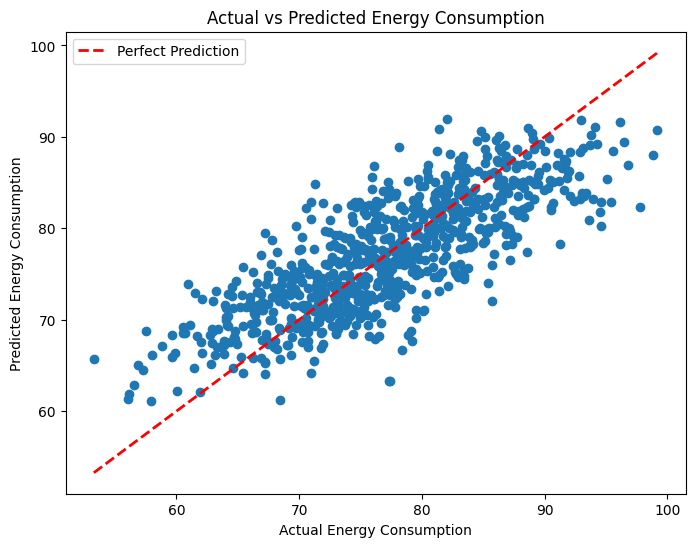

In [215]:
# Train final LinearRegression model for visualization
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])
model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_train)

plt.figure(figsize=(8, 6))
plt.scatter(y_train, y_pred)
# Add perfect prediction line
min_val = min(y_train.min(), y_pred.min())
max_val = max(y_train.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Energy Consumption")
plt.ylabel("Predicted Energy Consumption")
plt.title("Actual vs Predicted Energy Consumption")
plt.legend()
plt.show()


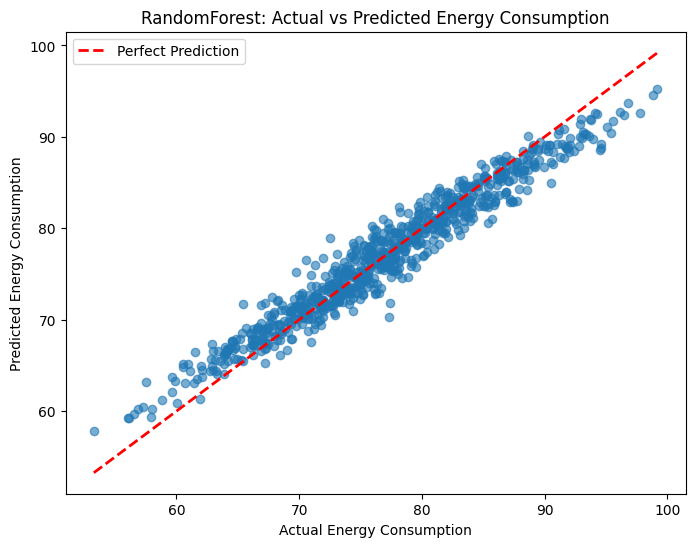

In [216]:
# Train RandomForest model for visualization
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=100, random_state=42))
])
rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_train)

plt.figure(figsize=(8, 6))
plt.scatter(y_train, y_pred_rf, alpha=0.6)
# Add perfect prediction line
min_val = min(y_train.min(), y_pred_rf.min())
max_val = max(y_train.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Energy Consumption")
plt.ylabel("Predicted Energy Consumption")
plt.title("RandomForest: Actual vs Predicted Energy Consumption")
plt.legend()
plt.show()
